# Decision Tree Training

This notebook demonstrates model training, model tuning, cross-validation, and final evaluation on the Iris dataset.
``

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

## Dataset Splitting

Training Set:
Used to fit the model.

Validation Set:
Used to choose model settings.

Test Set:
Used only once for final evaluation.

In [3]:
def split_data(X, y):

    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=0.1,
        stratify=y,
        random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.2,
        stratify=y_temp,
        random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (108, 4)
Validation: (27, 4)
Test: (15, 4)


## Model Complexity: Testing Different max_depth Values

The maximum depth controls the complexity of the decision tree.

Small depths may underfit the data, while large depths may overfit the training set.

The best depth is selected based on validation error, not test accuracy.

In [5]:
depths = range(1, 11)

train_errors = []
val_errors = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_errors.append(1 - train_acc)
    val_errors.append(1 - val_acc)

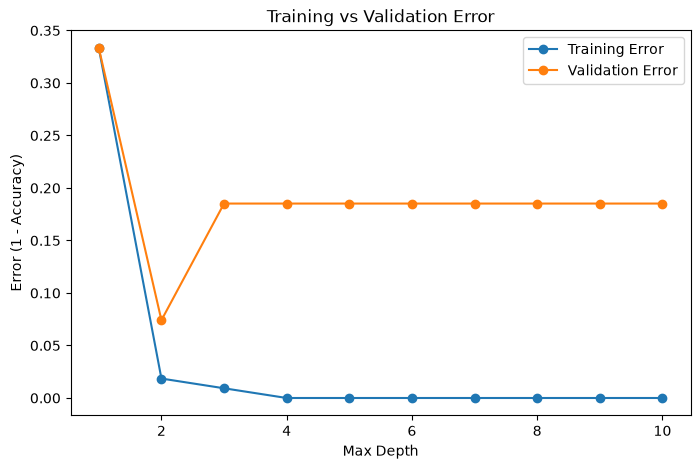

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    depths,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    depths,
    val_errors,
    marker="o",
    label="Validation Error"
)

plt.xlabel("Max Depth")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Training vs Validation Error")

plt.legend()

plt.show()


In [8]:
best_depth = depths[np.argmin(val_errors)]

print("Best Max Depth:", best_depth)
print("Lowest Validation Error:", min(val_errors))

Best Max Depth: 2
Lowest Validation Error: 0.07407407407407407


### Interpretation

The lowest validation error was achieved at a maximum depth of 2.

Trees with very small depth may underfit the data because they are too simple.

As tree depth increases, training error decreases. However, validation performance may not improve and can eventually worsen due to overfitting.

Therefore, max_depth = 2 was selected because it achieved the lowest validation error.

The test set was not used during model selection.

## Tuning min_samples_leaf

The minimum number of samples allowed in a leaf node controls tree complexity.

Larger values create simpler trees and help reduce overfitting.

In [11]:
leaf_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

leaf_validation_accuracy = []

for leaf in leaf_values:

    model = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    leaf_validation_accuracy.append(accuracy)

best_leaf = leaf_values[np.argmax(leaf_validation_accuracy)]

print("Best min_samples_leaf:", best_leaf)

Best min_samples_leaf: 1


### Interpretation

The best value for min_samples_leaf was 1.

The validation accuracy remained nearly constant across all tested values, indicating that the model is not highly sensitive to this parameter on the Iris dataset.

Therefore, min_samples_leaf had little influence on performance.

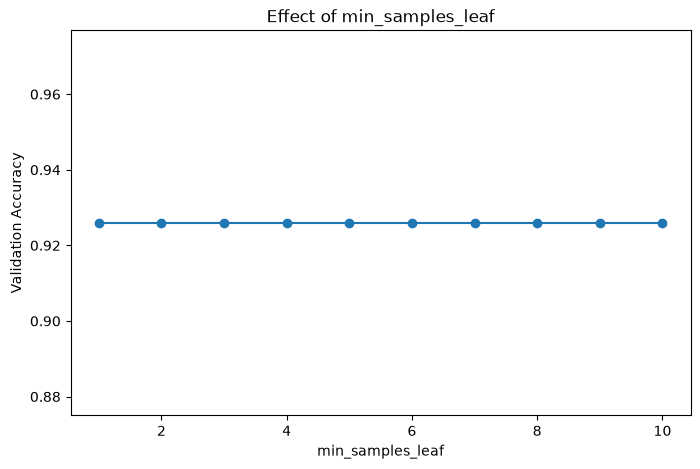

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    leaf_values,
    leaf_validation_accuracy,
    marker="o"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("Validation Accuracy")

plt.title("Effect of min_samples_leaf")

plt.show()

### Interpretation

Increasing min_samples_leaf reduces model complexity by requiring more samples in each leaf node.

Very large values can make the model too simple, while very small values may increase overfitting.

The value with the highest validation accuracy was selected.

### Interpretation

The validation accuracy remained almost unchanged for all tested values of min_samples_leaf.

This indicates that the selected tree structure is relatively stable and not highly sensitive to this parameter.

Therefore, changing min_samples_leaf had little effect on model performance for this dataset.

## Tuning min_samples_split

This parameter controls the minimum number of samples required before a node can be split.

Larger values reduce tree complexity and may help prevent overfitting.

In [12]:
split_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

split_validation_accuracy = []

for split in split_values:

    model = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    split_validation_accuracy.append(accuracy)

best_split = split_values[np.argmax(split_validation_accuracy)]

print("Best min_samples_split:", best_split)

Best min_samples_split: 2


### Interpretation

The best value for min_samples_split was 2.

This indicates that allowing splits whenever at least two samples are available produced the highest validation accuracy.

Increasing min_samples_split did not improve model performance for this dataset.

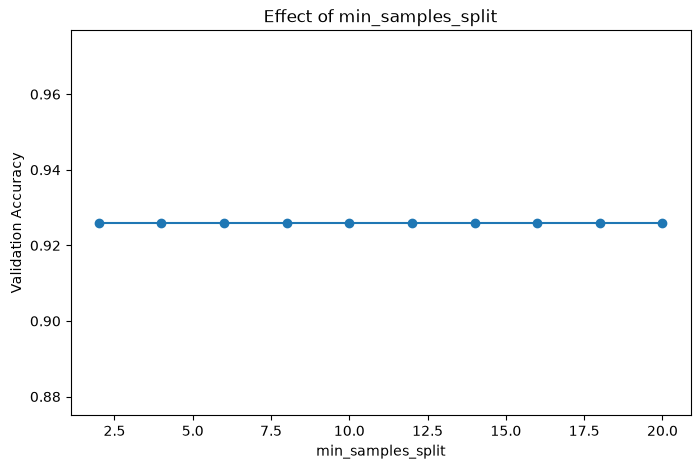

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    split_values,
    split_validation_accuracy,
    marker="o"
)

plt.xlabel("min_samples_split")
plt.ylabel("Validation Accuracy")

plt.title("Effect of min_samples_split")

plt.show()

### Interpretation

Increasing min_samples_split can simplify the tree by requiring more samples before creating a new split.

This helps control tree complexity and reduce the risk of overfitting.

The value with the highest validation accuracy was selected.

## Cost Complexity Pruning (ccp_alpha)

The ccp_alpha parameter prunes weak branches from the decision tree.

Higher values result in simpler trees and may improve generalization by reducing overfitting.

In [15]:
alpha_values = [0.0, 0.001, 0.005, 0.01, 0.02]

alpha_validation_accuracy = []

for alpha in alpha_values:

    model = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=best_leaf,
        min_samples_split=best_split,
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    alpha_validation_accuracy.append(accuracy)

best_alpha = alpha_values[np.argmax(alpha_validation_accuracy)]

print("Best ccp_alpha:", best_alpha)

Best ccp_alpha: 0.0


### Interpretation

The best ccp_alpha value was 0.0.

This indicates that pruning did not improve validation performance for this dataset.

The decision tree already generalizes well with the selected parameters, so additional pruning was unnecessary.

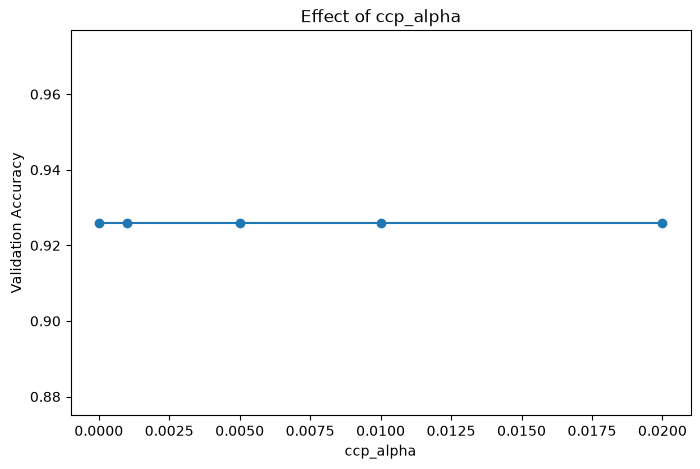

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    alpha_values,
    alpha_validation_accuracy,
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Validation Accuracy")
plt.title("Effect of ccp_alpha")

plt.show()

### Interpretation

Pruning removes unnecessary branches and simplifies the decision tree.

A small pruning value often performs best because excessive pruning may remove useful decision boundaries.

The value with the highest validation accuracy was selected.

## Comparing Unrestricted and Selected Trees

In [17]:
unrestricted_tree = DecisionTreeClassifier(
    random_state=42
)

unrestricted_tree.fit(X_train, y_train)

selected_tree = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    min_samples_split=best_split,
    ccp_alpha=best_alpha,
    random_state=42
)

selected_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

In [18]:
print("Unrestricted Tree")
print("Depth:", unrestricted_tree.get_depth())
print("Leaves:", unrestricted_tree.get_n_leaves())

print()

print("Selected Tree")
print("Depth:", selected_tree.get_depth())
print("Leaves:", selected_tree.get_n_leaves())

Unrestricted Tree
Depth: 4
Leaves: 6

Selected Tree
Depth: 2
Leaves: 3


In [19]:
unrestricted_train_acc = accuracy_score(
    y_train,
    unrestricted_tree.predict(X_train)
)

unrestricted_val_acc = accuracy_score(
    y_val,
    unrestricted_tree.predict(X_val)
)

selected_train_acc = accuracy_score(
    y_train,
    selected_tree.predict(X_train)
)

selected_val_acc = accuracy_score(
    y_val,
    selected_tree.predict(X_val)
)

print("Unrestricted Training Accuracy:", unrestricted_train_acc)
print("Unrestricted Validation Accuracy:", unrestricted_val_acc)

print()

print("Selected Training Accuracy:", selected_train_acc)
print("Selected Validation Accuracy:", selected_val_acc)

Unrestricted Training Accuracy: 1.0
Unrestricted Validation Accuracy: 0.8148148148148148

Selected Training Accuracy: 0.9814814814814815
Selected Validation Accuracy: 0.9259259259259259


### Interpretation

The unrestricted tree is more complex and contains more leaves.

The selected tree is smaller and easier to interpret.

Although both trees perform well, the selected tree achieves similar validation performance with lower complexity, making it a more reliable model.

In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

In [21]:
print("Depth:", unrestricted_tree.get_depth())
print("Leaves:", unrestricted_tree.get_n_leaves())

print("Depth:", selected_tree.get_depth())
print("Leaves:", selected_tree.get_n_leaves())

Depth: 4
Leaves: 6
Depth: 2
Leaves: 3


## Stratified 5-Fold Cross Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model on multiple training and validation splits.

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [23]:
cv_scores = cross_val_score(
    selected_tree,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print()

print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores:
[0.93333333 0.96666667 0.93333333 0.96666667 0.9       ]

Mean Accuracy: 0.9400000000000001
Standard Deviation: 0.024944382578492935


### Interpretation

Cross-validation evaluates the model across multiple data splits.

The mean accuracy represents the average model performance.

The standard deviation indicates how much performance varies between folds.

A small standard deviation suggests stable and reliable performance.

### Interpretation

The mean cross-validation accuracy was approximately 94%.

The standard deviation was small, indicating that performance remained consistent across different folds.

This suggests that the model is stable and generalizes well to unseen data.
``

In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [25]:
final_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_leaf=best_leaf,
    min_samples_split=best_split,
    ccp_alpha=best_alpha,
    random_state=42
)

final_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in

In [26]:
y_pred = final_model.predict(X_test)

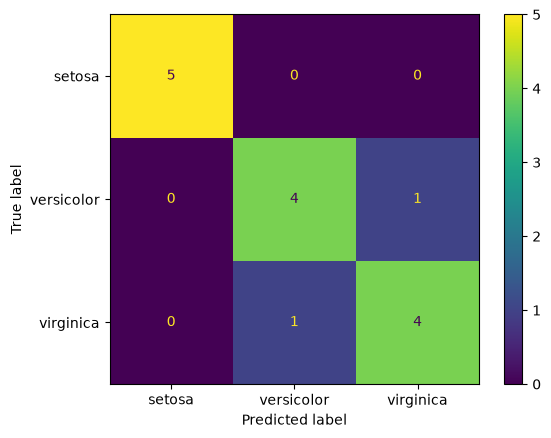

In [27]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot()
plt.show()

### Interpretation

The confusion matrix shows how many samples were correctly and incorrectly classified.

Setosa is usually classified correctly because it is well separated from the other species.

Most classification errors occur between Versicolor and Virginica because their feature distributions overlap.

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Test Accuracy:", test_accuracy)

In [28]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8666666666666667


## Final Test Evaluation

In [29]:
correct_predictions = (y_test == y_pred).sum()

print("Correct Predictions:", correct_predictions)
print("Total Test Samples:", len(y_test))

Correct Predictions: 13
Total Test Samples: 15


### Interpretation

The final test accuracy was approximately 0.87.

This means that 13 out of 15 test samples were classified correctly.

Although the test accuracy is not perfect, the test set contains only 15 samples.

Each prediction changes the accuracy by approximately 6.7%.

Therefore, the result should not be interpreted as definitively low, since a single prediction can have a noticeable effect on the reported accuracy.

The test set was used only once after model selection, ensuring a fair evaluation of model performance.
``

## Feature Scaling

Decision trees generally do not require feature scaling.

Unlike distance-based algorithms, decision trees make decisions using feature thresholds.

Therefore, scaling usually has little or no impact on decision tree performance.

If scaling is used as an experiment, it should be applied consistently to the training, validation, and test sets.